# Scaling ReLU Network Embeddings: discopt vs OMLT, and Depth vs Width

A trained ReLU network embedded in an optimization model becomes a mixed-integer
linear program (MILP): every neuron whose pre-activation can take either sign gets
one binary variable and four big-M constraints {cite:p}`Fischetti2018`. This
notebook asks two practical questions about that encoding.

1. **How does discopt scale against OMLT** {cite:p}`Ceccon2022`, the reference
   toolkit for this class, as the network grows? Both are run on the same
   networks, and both hand the MILP to HiGHS {cite:p}`Huangfu2018`, which is
   discopt's default backend for pure LP/MILP models.
2. **At a fixed neuron budget, is it better to go wide or deep?** The answer
   matters when you design a surrogate you intend to optimize over, not only
   predict with.

Everything below is measured, with the instrument named, and solve results are
loaded from the CSV files committed next to this notebook rather than re-run
here, so the numbers are exactly the ones discussed. The one live computation is
the interval-bound analysis in the depth-vs-width section, which takes
milliseconds. Commands to reproduce every table are at the end.

For the modeling API itself see {doc}`nn_embedding`; for the strength of the
big-M formulation and its alternatives see {cite:t}`Anderson2020`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data/relu_scaling")
sweep = pd.read_csv(DATA / "sweep_relu_bigm.csv")
split = pd.read_csv(DATA / "timing_split.csv")
slack = pd.read_csv(DATA / "slack_vs_native.csv")
dw = pd.read_csv(DATA / "depth_width.csv")
ARM = {"discopt": "discopt", "omlt+ref": "OMLT + HiGHS", "omlt+highs": "OMLT + HiGHS"}
print({k: len(v) for k, v in dict(sweep=sweep, split=split, slack=slack, depth_width=dw).items()})

{'sweep': 96, 'split': 84, 'slack': 354, 'depth_width': 45}


## Setup and provenance

| | |
|---|---|
| Networks | 2 inputs in $[-1,1]^2$, $L$ hidden ReLU layers of width $w$, 1 linear output; weights $\mathcal N(0, 1/\text{fan-in})$, biases $\mathcal N(0, 0.1^2)$; objective: minimize the output |
| discopt | `discopt.ml.add_predictor(..., method="relu_bigm")` → default LP/MILP route → HiGHS |
| OMLT | OMLT 1.2.2 `ReluBigMFormulation` → Pyomo 6.10.1 `SolverFactory("highs")` |
| Solver | HiGHS 1.15.1 via `highspy`, identical options in both arms (only `time_limit` set) |
| Machine | 4-core Intel Xeon @ 2.8 GHz; per-row load recorded where available |
| Code | sweep: `main` at `e1a5388`; timing split, slack experiment, depth vs width: `main` at `b7178ea` |

Two caveats apply throughout. The weights are **random, not trained**: random
networks have almost no *stable* neurons, so they are close to the hardest case
for a given size. And there are only **2 inputs**, so the networks are small in
input dimension and large only in their hidden layers.

## 1. Model size: the two encodings are the same size

Both encodings add one binary per *unstable* hidden neuron. discopt's
`relu_bigm` formulation uses the interval bounds to drop the binary for any
neuron that is provably always on or always off, which is why it occasionally
has one binary fewer.

In [2]:
size = (sweep.query("seed == 0 and arm in ['discopt', 'omlt+ref']")
        .pivot_table(index=["depth", "width"], columns="arm", values=["vars", "bins"])
        .astype(int))
size.columns = [f"{v} ({ARM[a]})" for v, a in size.columns]
size

bins (discopt)  bins (OMLT + HiGHS)  vars (discopt)  \
depth width                                                        
1     10                  9                   10              34   
      25                 25                   25              80   
      50                 50                   50             155   
      100                99                  100             304   
2     10                 19                   20              64   
      25                 50                   50             155   
      50                100                  100             305   
      100               199                  200             604   
3     10                 29                   30              94   
      25                 75                   75             230   
      50                150                  150             455   
      100               299                  300             904   

             vars (OMLT + HiGHS)  
depth width                       
1     10                      40  
      25                      85  
      50                     160  
      100                    310  
2     10                      70  
      25                     160  
      50                     310  
      100                    610  
3     10                     100  
      25                     235  
      50                     460  
      100                    910

## 2. Scaling: same instances solved, same answers

Each instance was solved by both tools with a 30 s limit, two seeds per size.

In [3]:
cert = (sweep[sweep.arm.isin(["discopt", "omlt+ref"])]
        .groupby(["depth", "width", "arm"]).cert.sum().unstack("arm").astype(int))
cert.columns = [f"certified, {ARM[a]} (of 2)" for a in cert.columns]
both = sweep.pivot_table(index=["depth", "width", "seed"], columns="arm", values="objective")
agree = both.dropna(subset=["discopt", "omlt+ref"])
print("certified objectives that disagree by more than 1e-6:",
      int((abs(agree["discopt"] - agree["omlt+ref"]) > 1e-6).sum()), "of", len(agree))
cert

certified objectives that disagree by more than 1e-6: 0 of 14


certified, discopt (of 2)  certified, OMLT + HiGHS (of 2)
depth width                                                           
1     10                             2                               2
      25                             2                               2
      50                             2                               2
      100                            2                               2
2     10                             2                               2
      25                             2                               2
      50                             0                               0
      100                            0                               0
3     10                             2                               2
      25                             0                               0
      50                             0                               0
      100                            0                               0

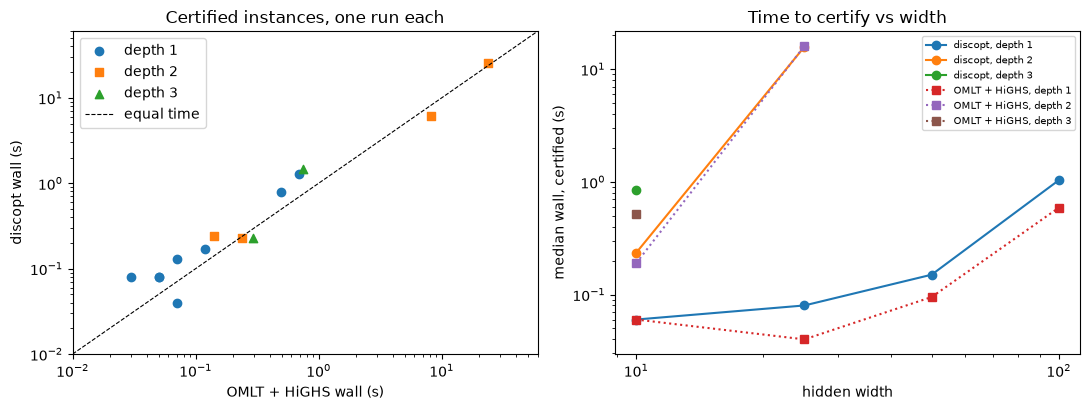

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ok = sweep[sweep.cert == 1].pivot_table(index=["depth", "width", "seed"], columns="arm", values="wall")
ok = ok.dropna(subset=["discopt", "omlt+ref"])
ax = axes[0]
for d, mk in zip((1, 2, 3), "os^"):
    sub = ok.xs(d, level="depth")
    ax.scatter(sub["omlt+ref"], sub["discopt"], marker=mk, label=f"depth {d}")
lim = [0.01, 60]
ax.plot(lim, lim, "k--", lw=0.8, label="equal time")
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
       xlabel="OMLT + HiGHS wall (s)", ylabel="discopt wall (s)",
       title="Certified instances, one run each")
ax.legend()

ax = axes[1]
for arm, mk in (("discopt", "o"), ("omlt+ref", "s")):
    g = sweep[(sweep.arm == arm) & (sweep.cert == 1)].groupby(["depth", "width"]).wall.median()
    for d in (1, 2, 3):
        if d in g.index.get_level_values(0):
            s = g.xs(d)
            ax.plot(s.index, s.values, marker=mk, ls="-" if arm == "discopt" else ":",
                    label=f"{ARM[arm]}, depth {d}")
ax.set(xscale="log", yscale="log", xlabel="hidden width", ylabel="median wall, certified (s)",
       title="Time to certify vs width")
ax.legend(fontsize=7)
fig.tight_layout()

On the instances that neither tool certified, compare what each had *found*. The
sweep also ran SCIP on discopt's model (`discopt+scip`), which is shown here only
for this comparison.

In [5]:
unc = sweep.groupby(["width", "depth", "seed"]).filter(
    lambda g: not g[g.arm.isin(["discopt", "omlt+ref"])].cert.any())
inc = (unc.assign(has_incumbent=unc.objective.notna())
          .groupby("arm").agg(instances=("has_incumbent", "size"),
                              with_incumbent=("has_incumbent", "sum")))
inc.index = [{"discopt+scip": "SCIP (on discopt's model)", "omlt+discopt": "discopt (on OMLT's model)"}
             .get(a, ARM.get(a, a)) for a in inc.index]
inc

,instances,with_incumbent
discopt,10,0
SCIP (on discopt's model),10,10
discopt (on OMLT's model),10,0
OMLT + HiGHS,10,0


**Reading.** Both tools certify exactly the same instances at every size, and
every certified objective agrees. Both stop certifying within 30 s at the same
point — **depth 2 at width 50, depth 3 at width 25** — while every depth-1
network up to width 100 solves in about a second. Model size alone does not set
the difficulty: 100×1 (99 binaries) solves in about a second, while 25×3
(75 binaries) does not finish.

These are single runs, so the scatter in the left panel mixes real differences
with run-to-run noise. The next section repeats a subset to separate the two.

## 3. Where the time goes (repeated, interleaved)

Each solve ran in a fresh process after an untimed warm-up solve (so imports and
first-call setup are excluded), the two tools alternated, and every
`highspy.Highs.run` call was timed. *Overhead* is wall time outside HiGHS:
model extraction, translation, and in discopt's case the certificate checks.

In [6]:
split["total"] = split["build"] + split["solve"]
split["overhead"] = split["solve"] - split["highs"]
g = split.groupby(["spec", "arm"])
summary = pd.DataFrame({
    "n": g.size(),
    "total median (s)": g.total.median(),
    "total sd (s)": g.total.std(),
    "overhead median (s)": g.overhead.median(),
    "HiGHS median (s)": g.highs.median(),
    "HiGHS calls": g.highs_calls.median().astype(int),
}).round(3)
summary.index = summary.index.set_levels([summary.index.levels[0], [ARM[a] for a in summary.index.levels[1]]])
summary

n  total median (s)  total sd (s)  overhead median (s)  \
spec    arm                                                                    
100:1:0 discopt       6             1.565         0.232                0.294   
        OMLT + HiGHS  6             0.748         0.061                0.058   
100:1:1 discopt       6             0.627         0.019                0.270   
        OMLT + HiGHS  6             0.589         0.037                0.053   
100:2:0 discopt       3            30.238         0.159                0.966   
        OMLT + HiGHS  3            30.346         0.034                0.133   
10:3:0  discopt       6             1.790         0.047                0.115   
        OMLT + HiGHS  6             0.954         0.027                0.023   
10:3:1  discopt       6             0.334         0.008                0.120   
        OMLT + HiGHS  6             0.393         0.009                0.022   
25:2:0  discopt       6            30.031         0.011                0.157   
        OMLT + HiGHS  6            29.856         0.519                0.033   
25:2:1  discopt       6             7.967         0.226                0.170   
        OMLT + HiGHS  6             9.931         0.389                0.033   
50:3:0  discopt       3            30.199         0.013                0.609   
        OMLT + HiGHS  3            30.186         0.012                0.093   

                      HiGHS median (s)  HiGHS calls  
spec    arm                                          
100:1:0 discopt                  1.223            5  
        OMLT + HiGHS             0.662            1  
100:1:1 discopt                  0.339            5  
        OMLT + HiGHS             0.518            1  
100:2:0 discopt                 29.177            1  
        OMLT + HiGHS            30.012            1  
10:3:0  discopt                  1.671            5  
        OMLT + HiGHS             0.919            1  
10:3:1  discopt                  0.207            5  
        OMLT + HiGHS             0.358            1  
25:2:0  discopt                 29.872            2  
        OMLT + HiGHS            29.802            1  
25:2:1  discopt                  7.762            5  
        OMLT + HiGHS             9.861            1  
50:3:0  discopt                 29.556            1  
        OMLT + HiGHS            30.007            1

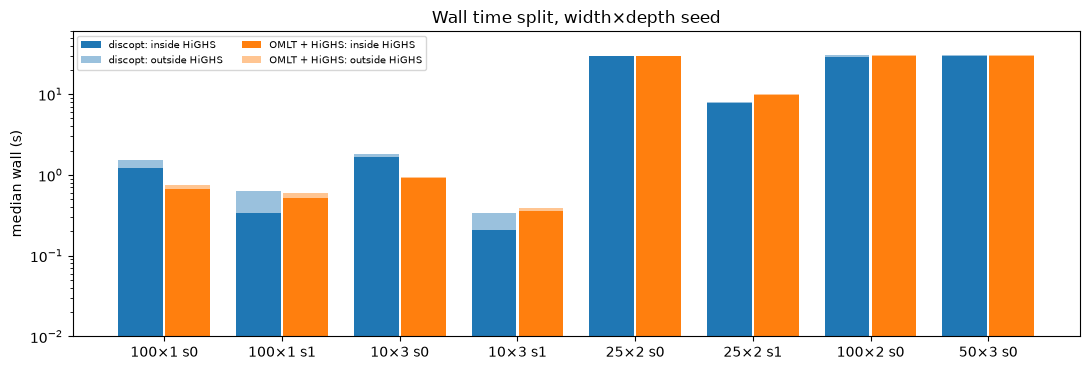

In [7]:
specs = list(dict.fromkeys(split.spec))
fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(specs))
for k, (arm, off) in enumerate((("discopt", -0.2), ("omlt+highs", 0.2))):
    s = split[split.arm == arm].groupby("spec")
    hi = s.highs.median().reindex(specs)
    ov = (s.overhead.median() + s.build.median()).reindex(specs)
    ax.bar(x + off, hi, 0.38, label=f"{ARM[arm]}: inside HiGHS", color=f"C{k}")
    ax.bar(x + off, ov, 0.38, bottom=hi, label=f"{ARM[arm]}: outside HiGHS", color=f"C{k}", alpha=0.45)
ax.set_xticks(x, [s.replace(":", "×", 1).replace(":", " s") for s in specs])
ax.set(yscale="log", ylim=(0.01, 60), ylabel="median wall (s)",
       title="Wall time split, width×depth seed")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()

**Reading.**

* discopt has a **fixed overhead of roughly 0.1–0.3 s per solve** outside HiGHS
  (Pyomo: 0.02–0.06 s). It is extraction, the standard form, and the certificate
  work — discopt does not take HiGHS's word for the answer; it re-verifies the
  incumbent and cross-checks the bound with extra LP solves. Those extra
  `Highs.run` calls (the 5 vs 1 in the table) are not where the time goes:
  instrumented on 10×3 seed 0 they cost 7 ms of a 1.87 s solve (recorded in
  `docs/dev/lp-milp-highs-routing-plan.md` §12), so the overhead is mostly
  Python-side.
* **Inside HiGHS the time goes both ways.** discopt is faster on some
  instances and slower on others. MIP search is chaotic: two algebraically
  equivalent models routinely take different branch-and-bound paths.
* **At the time limit** OMLT's final dual bound is tighter on 50×3 (−13.06 vs
  −13.75), identically on every repeat. discopt's overhead there is about 0.6 s
  of 30 s, so this is the model and search path, not lost time budget.

## 4. Why discopt can be slower: the standard form

discopt's LP/MILP route hands HiGHS the model in *standard form*,
$\min c^\top x$ s.t. $Ax=b,\ \ell\le x\le u$, with one *slack* column per
inequality row. That is deliberate. discopt certifies every LP answer itself, and
its certificates — a rigorous lower bound from HiGHS's duals, infeasibility rays,
a phase-1 proof — are all stated for that form. Solving exactly the form being
verified means HiGHS's duals and rays refer to the very rows and columns that are
checked, with no translation layer to get wrong. For an LP that is the right
trade.

For a MILP it costs: the branch-and-cut sees about twice as many columns
(10×3: 210 vs OMLT's 100). The MILP's certificate does not depend on the slack
columns, so an experiment folded each slack back into its row's bounds — the
*same* model, minus the slack columns — and timed HiGHS on both forms
(issue `#1600`).

In [8]:
fin = slack.groupby(["name", "form"]).agg(wall=("wall", "median"), status=("status", "first")).unstack("form")
fin = fin[(fin["status"]["std"] == "Optimal") & (fin["status"]["native"] == "Optimal")]
fin = pd.DataFrame({"std": fin["wall"]["std"], "native": fin["wall"]["native"]})
def family(n):
    if n.startswith("relu"):
        return "ReLU depth " + n.split("x")[1][0]
    return {"mknap": "knapsack", "cfl": "facility location", "setcover": "set cover",
            "lotsize": "lot sizing"}[n.split("_")[0]]
fin["family"] = [family(n) for n in fin.index]
fin["ratio"] = fin["native"] / fin["std"]
tab = fin.groupby("family").agg(
    n=("ratio", "size"),
    geomean_ratio=("ratio", lambda r: float(np.exp(np.log(r).mean()))),
    native_faster=("ratio", lambda r: int((r < 1).sum())),
    total_std_s=("std", "sum"), total_native_s=("native", "sum"))
tab["total_ratio"] = tab.total_native_s / tab.total_std_s
print(f"{len(fin)} instances: median ratio {fin.ratio.median():.3f}, native faster on "
      f"{int((fin.ratio < 1).sum())}/{len(fin)}, total {fin['std'].sum():.1f} s -> {fin['native'].sum():.1f} s")
tab.sort_values("total_ratio").round(3)

59 instances: median ratio 0.805, native faster on 37/59, total 168.6 s -> 112.1 s


,n,geomean_ratio,native_faster,total_std_s,total_native_s,total_ratio
family,,,,,,
set cover,6,0.540,6,76.747,41.603,0.542
facility location,6,0.691,5,1.896,1.046,0.552
ReLU depth 2,10,0.909,6,63.518,44.862,0.706
ReLU depth 1,20,0.936,11,6.167,4.756,0.771
knapsack,6,0.815,4,12.602,11.449,0.909
lot sizing,6,1.043,3,1.042,1.035,0.993
ReLU depth 3,5,1.303,2,6.672,7.383,1.107


Without the slack columns HiGHS is faster in aggregate — total time down about a
third — with the gain concentrated on the larger, harder models (set cover,
facility location, depth-2 networks). Instance by instance it is noisy, for the
same search-path reason as above. **The route is deliberately not changed**
(`#1600`, closed as not planned): certification is already at parity, the gain is
wall time only and inconsistent per instance, and it would put a second model
representation on a route whose rule is that what HiGHS solves is exactly what
discopt verifies. It would be revisited if MILP wall time became a priority or a
broad MILP panel showed a consistent win.

**In short:** at equal model size discopt is at parity with OMLT on *which*
instances it solves and *what* answer it returns. It pays a small fixed cost
for verifying the answer, and a variable cost for the standard form, which is
kept on purpose.

## 5. Depth vs width

Hold the number of hidden neurons fixed and vary how they are arranged: 60
neurons as 60×1, 30×2, 20×3, 15×4, 12×5 or 10×6. The number of binaries barely
changes — nearly every neuron of a random network is unstable — so if difficulty
tracked the binary count, all arrangements would be equally hard.

### The mechanism: bounds loosen layer by layer

The big-M constants come from interval bounds on each neuron's pre-activation,
propagated layer by layer from the input box (`discopt.ml.bounds.propagate_bounds`,
the same routine the formulation uses). Interval arithmetic cannot see
correlations between neurons, so every layer widens the intervals of the next.
Deeper layers get looser bounds, larger big-M constants, and a weaker LP
relaxation.

median_width  unstable  neurons
     layer                                 
60x1 1          1.986236        59       60
30x2 1          1.881663        30       30
     2          4.435060        30       30
20x3 1          1.770387        20       20
     2          3.152288        20       20
     3          4.934005        20       20
10x6 1          1.682028         9       10
     2          2.441509        10       10
     3          3.064234        10       10
     4          3.666400        10       10
     5          3.236683        10       10
     6          3.595465        10       10

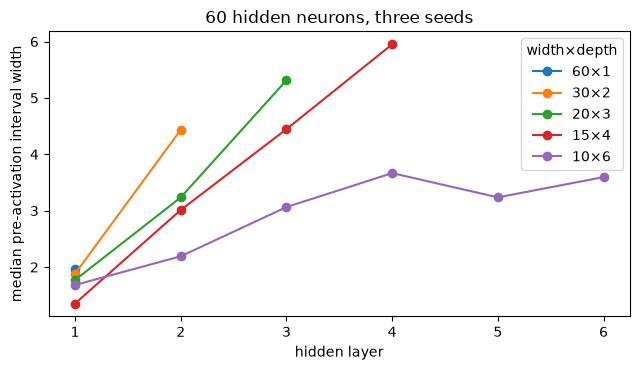

In [9]:
from discopt.ml.bounds import propagate_bounds
from discopt.ml.network import DenseLayer, NetworkDefinition


def make_net(d, width, depth, act, seed):
    # identical to discopt_benchmarks/scripts/omlt_scaling_panel.py::make_net
    rng = np.random.default_rng(seed)
    sizes = [d] + [width] * depth + [1]
    return [(rng.normal(0, 1 / np.sqrt(a), size=(a, b)), rng.normal(0, 0.1, size=b),
             act if i < depth else "linear")
            for i, (a, b) in enumerate(zip(sizes[:-1], sizes[1:], strict=True))]


def layer_bounds(budget, depth, seed=0, box=1.0):
    layers = make_net(2, budget // depth, depth, "relu", seed)
    net = NetworkDefinition([DenseLayer(w, b, a) for w, b, a in layers],
                            input_bounds=(np.full(2, -box), np.full(2, box)))
    out = []
    for k, lb in enumerate(propagate_bounds(net)[:-1]):
        lo, hi = np.asarray(lb.pre_lb), np.asarray(lb.pre_ub)
        out.append(dict(layer=k + 1, median_width=float(np.median(hi - lo)),
                        unstable=int(((lo < 0) & (hi > 0)).sum()), neurons=len(lo)))
    return pd.DataFrame(out)


fig, ax = plt.subplots(figsize=(6.5, 3.8))
for depth in (1, 2, 3, 4, 6):
    t = pd.concat([layer_bounds(60, depth, s) for s in range(3)]).groupby("layer").median_width.median()
    ax.plot(t.index, t.values, marker="o", label=f"{60 // depth}×{depth}")
ax.set(xlabel="hidden layer", ylabel="median pre-activation interval width",
       title="60 hidden neurons, three seeds")
ax.legend(title="width×depth")
fig.tight_layout()
pd.concat({f"{60 // d}x{d}": layer_bounds(60, d).set_index("layer") for d in (1, 2, 3, 6)})

### The consequence: solve time at a fixed neuron budget

Hidden-neuron budgets of 60 and 120, depths 1–6, three seeds, 60 s limit, solved
by discopt with its default route. A timed-out solve is plotted at the limit.

width  binaries  certified  seeds  median_wall_s  median_big_M
budget depth                                                                
60     1         60      60.0          3      3           0.45          2.71
       2         30      60.0          3      3          15.19          4.88
       3         20      60.0          2      3          48.75          5.25
       4         15      60.0          0      3          60.01          5.73
       5         12      60.0          1      3          60.01          4.43
       6         10      60.0          1      3          60.02          4.35
120    1        120     120.0          3      3           2.09          3.19
       2         60     120.0          0      3          60.02          5.04
       3         40     120.0          0      3          60.02         11.15
       4         30     120.0          0      3          60.03         16.34
       5         24     120.0          0      3          60.02         22.68
       6         20     120.0          0      3          60.02         24.74

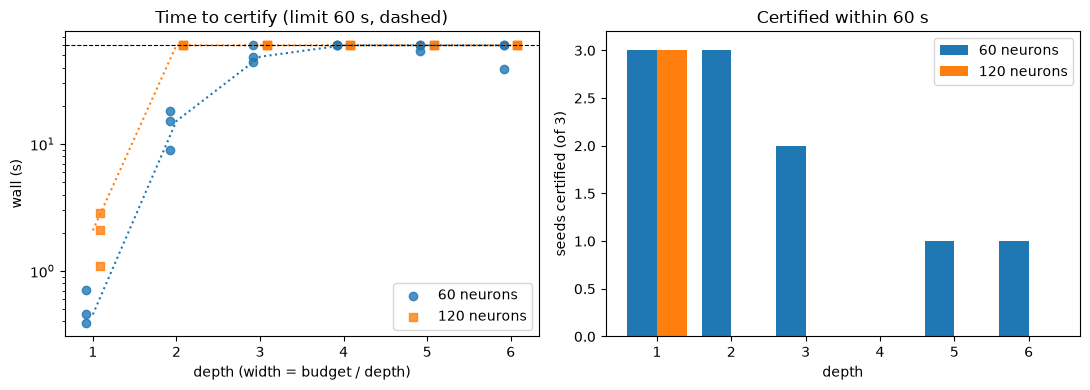

In [10]:
wide = dw[dw.box == 1.0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, (budget, mk) in enumerate(((60, "o"), (120, "s"))):
    s = wide[wide.budget == budget]
    axes[0].scatter(s.depth + (0.08 if budget == 120 else -0.08), s.wall, marker=mk,
                    label=f"{budget} neurons", alpha=0.8, color=f"C{k}")
    med = s.groupby("depth").wall.median()
    axes[0].plot(med.index, med.values, ls=":", color=f"C{k}")
    c = s.groupby("depth").cert.sum()
    axes[1].bar(c.index + (0.2 if budget == 120 else -0.2), c.values, 0.4,
                label=f"{budget} neurons", color=f"C{k}")
axes[0].axhline(60, color="k", lw=0.8, ls="--")
axes[0].set(yscale="log", xlabel="depth (width = budget / depth)", ylabel="wall (s)",
            title="Time to certify (limit 60 s, dashed)")
axes[1].set(xlabel="depth", ylabel="seeds certified (of 3)", ylim=(0, 3.2),
            title="Certified within 60 s")
for ax in axes:
    ax.legend()
fig.tight_layout()
(wide.groupby(["budget", "depth"])
     .agg(width=("width", "first"), binaries=("binaries", "median"),
          certified=("cert", "sum"), seeds=("cert", "size"),
          median_wall_s=("wall", "median"), median_big_M=("big_m", "median"))
     .round(2))

### Input bounds

The same networks with the input box narrowed from $[-1,1]^2$ to
$[-0.25,0.25]^2$. Narrower inputs shrink every interval downstream, which
stabilizes neurons (fewer binaries) and shrinks the big-M constants.

In [11]:
nar = dw[dw.box < 1.0][["budget", "depth", "seed"]].drop_duplicates()
cmp = dw.merge(nar, on=["budget", "depth", "seed"])
(cmp.pivot_table(index=["budget", "depth", "seed"], columns="box",
                 values=["binaries", "big_m", "wall", "cert"])
    .round(2))

big_m        binaries        cert        wall       
box                0.25   1.00     0.25   1.00 0.25 1.00   0.25   1.00
budget depth seed                                                     
60     3     0     1.38   4.29     57.0   60.0  1.0  1.0  10.06  48.75
             1     1.37   5.25     59.0   60.0  1.0  0.0  34.02  60.02
             2     1.51   5.69     56.0   60.0  1.0  1.0  12.32  44.48
       4     0     1.61   5.71     57.0   60.0  1.0  0.0   6.27  60.04
             1     1.60   5.73     54.0   59.0  1.0  0.0   9.65  60.01
             2     1.82   7.24     59.0   60.0  1.0  0.0  43.41  60.01
120    3     0     3.12  12.00    118.0  120.0  0.0  0.0  60.05  60.02
             1     2.76  11.15    115.0  119.0  0.0  0.0  60.02  60.03
             2     2.77  10.78    118.0  120.0  0.0  0.0  60.02  60.02

### Reading

* **Same binaries, very different difficulty.** At 60 neurons every arrangement
  has 59–60 binaries, yet 60×1 certifies in under a second, 30×2 in about 15 s,
  20×3 in about 50 s (two seeds of three), and from depth 4 on nearly nothing
  certifies within 60 s. At 120 neurons only the single-layer network certifies
  (about 2 s); every deeper arrangement times out.
* **The big-M constants track the bound loosening.** At 120 neurons the median
  largest big-M grows from 3.2 (one layer) to 11 (three layers) and 25 (six
  layers), exactly the layer-by-layer widening shown above.
* **Beyond depth 3 the trend is not perfectly monotone** at the 60-neuron budget
  (depths 5 and 6 each certify one seed of three; depth 4 none). That is
  consistent with the mechanism plot, where very narrow layers widen the intervals
  less per layer, but three seeds cannot settle it. All three depths are far
  harder than one or two layers.
* **Input bounds matter a lot.** Narrowing the input box from $\pm 1$ to
  $\pm 0.25$ stabilized only a few neurons (59–60 → 54–59 binaries) but shrank
  the big-M constants 3–4× (per seed, 3.1× to 4.0×), and took the 60-neuron depth-3 and depth-4
  networks from 2 of 6 certified to 6 of 6. It was not enough for 120×3.

## 6. Best practices for optimizing over a ReLU network

Each recommendation is tied to the evidence above or to the literature.

1. **Prefer wide and shallow when you have a choice.** At a fixed neuron budget
   the binary count is the same, but every extra layer loosens the big-M bounds
   of all the layers after it (Section 5). If a shallower network fits your data
   nearly as well, it is far cheaper to optimize over. Deeper networks can
   represent more linear regions per neuron {cite:p}`Serra2018` — that is the
   expressivity you pay for.
2. **Bound the inputs as tightly as the application allows.** The input box is
   the seed of every big-M constant. Narrowing it stabilizes neurons (they lose
   their binaries entirely) and shrinks the remaining constants (Section 5).
   Declare tight bounds on the input variables, or pass `input_bounds=` to
   `add_predictor`.
3. **Stable neurons are free; train for them.** A neuron that is provably
   always on or always off needs no binary, and discopt drops it automatically
   (Section 1). Regularizers that push pre-activations away from zero make far
   more neurons stable and the MILP correspondingly smaller
   {cite:p}`Xiao2019`; tighter per-neuron bounds have the same effect
   {cite:p}`Tjeng2019`.
4. **Expect difficulty to grow with depth, not just size.** In the sweep, every
   depth-1 network up to 100 neurons certified in about a second; depth 2 ran
   out of time at 100 neurons and depth 3 at 75 (Section 2). Budget time
   accordingly.
5. **For a solution fast, not a proof, watch the incumbent.** On the networks
   neither tool certified in 30 s, HiGHS (and therefore discopt and OMLT+HiGHS)
   had not found *any* feasible point, while SCIP found one on every such
   instance in the same benchmark (Section 2's sweep, SCIP arm). If you need a
   good point quickly on a large network, supply an initial point (for example
   the network evaluated at a sensible input) or use a solver with stronger
   primal heuristics.
6. **Use ReLU, not smooth activations, if you intend to certify.** The ReLU
   embedding is a MILP that discopt and OMLT solve equally well. Smooth
   activations (sigmoid, tanh) become nonconvex nonlinear programs, which are much
   harder to certify. In the same benchmark run (at `e1a5388`, sigmoid full-space,
   same grid of sizes) discopt certified 0 of 24 networks against 20 of 24 for
   OMLT with SCIP. Those numbers predate array-row bound propagation (#1568,
   since made the default), which was aimed at exactly this gap; they are not
   reproduced here and should be re-measured before being relied on.

## 7. Caveats

* Random networks, not trained ones. Trained networks typically have many more
  stable neurons and are easier at the same size.
* Two inputs only; one machine; a single solver backend (HiGHS) for the MILP.
* The scaling sweep is one run per instance; Section 3's repeats are the timing
  evidence.

## 8. Reproduce

The scripts live in `discopt_benchmarks/scripts/`:

```bash
# Section 2 (both tools, sizes x seeds; --forms relu:bigm for this notebook)
python -u omlt_scaling_panel.py --forms relu:bigm --out sweep.tsv
# Section 3 (repeated, interleaved, with the HiGHS-time split)
python -u relu_timing_split.py --reps 6 --tl 30 --out timing_split.tsv
# Section 4 (slack vs native rows)
python -u milp_slack_vs_native_rows.py --tl 60 --reps 3 --out slack_vs_native.tsv
# Section 5 (depth vs width)
python -u relu_depth_width.py --tl 60 --out depth_width.tsv
```

The CSV files in `docs/notebooks/data/relu_scaling/` are those outputs.